In [3]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv


In [4]:
load_dotenv()
data_dir = Path(os.getenv('DATA_FILE_DIR'))
path2processed = data_dir /'log_processed.csv'

In [5]:
df = pd.read_csv(path2processed, parse_dates=['datetime'], dtype={'status_Code': 'Int64', 'lat': 'Float64', 'lon': 'Float64'})

In [6]:
df.head()

,ip_address,datetime,request_type,endpoint,http_version,status_code,user_agent,Agent_Type,country,countryCode,region,regionName,city,zip,lat,lon,timezone
0,129.146.237.0,2026-07-12 11:11:43+00:00,GET,/blog/0,HTTP/1.1,200,Scrapy/2.16.0 (+https://scrapy.org),R,United States,US,AZ,Arizona,Phoenix,85008,33.4656,-111.9956,America/Phoenix
1,47.82.11.184,2026-07-12 11:12:43+00:00,GET,/robots.txt,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,R,Singapore,SG,3,North West,Singapore,858877,1.35208,103.82,Asia/Singapore
2,47.82.11.184,2026-07-12 11:12:52+00:00,GET,/sitemap_news.xml.gz,HTTP/1.1,404,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,H,Singapore,SG,3,North West,Singapore,858877,1.35208,103.82,Asia/Singapore
3,40.77.167.144,2026-07-12 11:20:49+00:00,GET,/,HTTP/1.1,200,"Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Ge...",R,United States,US,VA,Virginia,Boydton,23917,36.677696,-78.37471,America/New_York
4,17.241.227.225,2026-07-12 11:26:03+00:00,GET,/photos/france,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,R,United States,US,CA,California,Cupertino,95014,37.3322,-122.011,America/Los_Angeles


In [7]:
groups = df.groupby('Agent_Type')

In [8]:
groups['ip_address'].count()

Agent_Type
H    1566
R    1473
Name: ip_address, dtype: int64

In [9]:
min_date = df['datetime'].min().strftime("%Y-%m-%d")
max_date = df['datetime'].max().strftime("%Y-%m-%d")

In [10]:
groups.get_group('H')

,ip_address,datetime,request_type,endpoint,http_version,status_code,user_agent,Agent_Type,country,countryCode,region,regionName,city,zip,lat,lon,timezone
2,47.82.11.184,2026-07-12 11:12:52+00:00,GET,/sitemap_news.xml.gz,HTTP/1.1,404,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,H,Singapore,SG,3,North West,Singapore,858877,1.35208,103.82,Asia/Singapore
5,154.159.252.207,2026-07-12 12:02:19+00:00,GET,/photos/australia,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10) ...,H,Kenya,KE,30,Nairobi County,Nairobi,9831,-1.2841,36.8155,Africa/Nairobi
7,171.250.162.196,2026-07-12 12:35:37+00:00,GET,/,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 11_3_1)...,H,Vietnam,VN,SG,Ho Chi Minh,Ho Chi Minh City,700000,10.822,106.6257,Asia/Ho_Chi_Minh
8,190.62.87.242,2026-07-12 13:21:14+00:00,GET,/blog/0,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,H,El Salvador,SV,SS,San Salvador Department,San Salvador,NaN,13.6927,-89.1917,America/El_Salvador
9,138.84.33.34,2026-07-12 14:59:35+00:00,GET,/,HTTP/1.1,200,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...,H,Chile,CL,RM,Santiago Metropolitan,Santiago,NaN,-33.4488,-70.6692,America/Santiago
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3032,190.97.232.134,2026-08-09 16:57:32+00:00,GET,/blog/8,HTTP/1.1,200,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,H,Venezuela,VE,E,Barinas,Sabaneta,NaN,8.75234,-69.9335,America/Caracas
3033,14.134.19.150,2026-08-09 16:57:44+00:00,GET,/blog/8,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 11_0_0)...,H,China,CN,NX,Ningxia,Yinchuan,750000,38.4712,106.259,Asia/Shanghai
3034,101.249.128.108,2026-08-09 16:58:21+00:00,GET,/blog/8,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_12_6...,H,China,CN,XZ,Tibet,Jibenggang,NaN,29.6472,91.1174,Asia/Shanghai
3035,223.109.46.104,2026-08-09 16:58:29+00:00,GET,/blog/8,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 11_0_0)...,H,China,CN,JS,Jiangsu,Nanjing,210000,32.0607,118.763,Asia/Shanghai


In [14]:
counts_human = groups.get_group('H').groupby('countryCode')['ip_address'].count().sort_values(ascending=False)

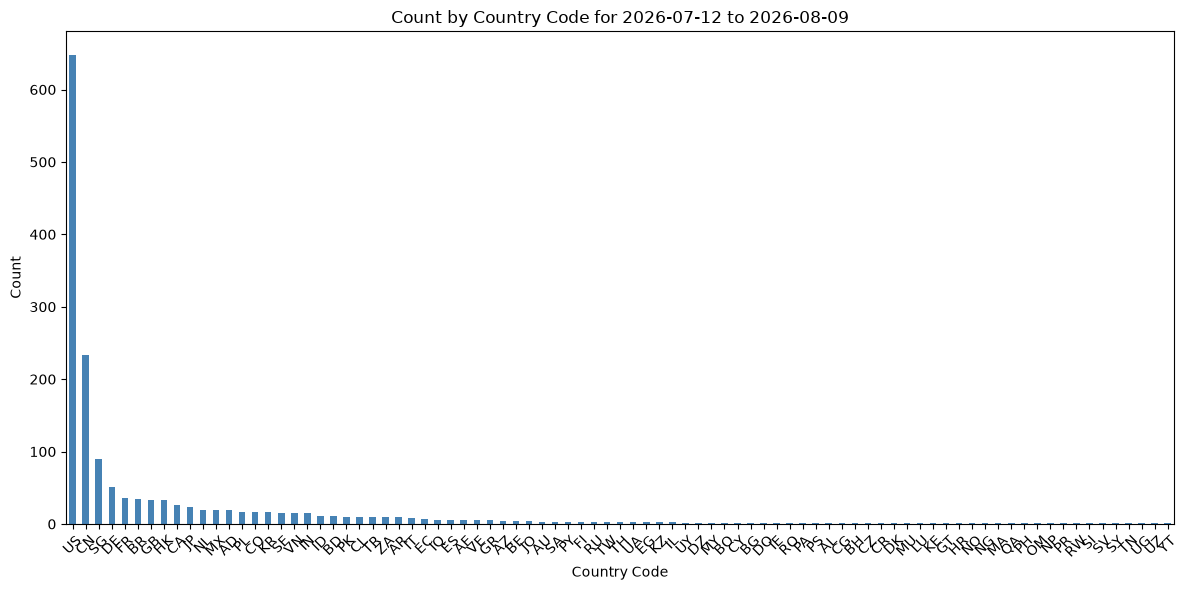

In [15]:

counts_human.plot(kind='bar', figsize=(12, 6), color='steelblue')
plt.title(f'Count by Country Code for {min_date} to {max_date}')
plt.xlabel('Country Code')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

In [18]:
groups.get_group('H').groupby('endpoint')['ip_address'].count().sort_values(ascending=False)


endpoint
/blog/4                    558
/blog/8                    142
/                          130
/blog/6                    102
/blog                       82
                          ... 
/webpack-stats.json          1
/wp-admin/install.php        1
/wp-admin/.git/config        1
/wp-content/.git/config      1
/wp/.git/config              1
Name: ip_address, Length: 77, dtype: int64

In [12]:
df_filtered = df.loc[df['endpoint'] == '/blog/4']

In [13]:
df_filtered

,ip_address,datetime,request_type,endpoint,http_version,status_code,user_agent,country,countryCode,region,regionName,city,zip,lat,lon,timezone
13,102.141.42.74,2026-07-12 17:57:09+00:00,GET,/blog/4,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,Congo Republic,CG,BZV,Brazzaville,Brazzaville,NaN,-4.256800,15.28720,Africa/Brazzaville
50,52.167.144.142,2026-07-13 09:33:36+00:00,GET,/blog/4,HTTP/1.1,200,"Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Ge...",United States,US,VA,Virginia,Boydton,23917,36.677696,-78.37471,America/New_York
91,20.194.1.8,2026-07-14 08:39:31+00:00,GET,/blog/4,HTTP/1.1,200,"Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Ge...",South Korea,KR,11,Seoul,Seoul,06181,37.566500,126.97800,Asia/Seoul
112,34.96.60.165,2026-07-14 22:11:21+00:00,GET,/blog/4,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,United States,US,IA,Iowa,Council Bluffs,NaN,41.261900,-95.86080,America/Chicago
119,54.39.203.84,2026-07-15 03:52:58+00:00,GET,/blog/4,HTTP/1.1,200,Mozilla/5.0 (compatible; AhrefsBot/7.0; +http:...,Canada,CA,QC,Quebec,Beauharnois,J6N,45.316100,-73.87360,America/Toronto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1158,142.111.59.144,2026-07-22 13:18:47+00:00,GET,/blog/4,HTTP/1.1,200,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,United States,US,UT,Utah,Orem,84097,40.303200,-111.67500,America/Denver
1173,27.152.183.246,2026-07-23 05:29:18+00:00,GET,/blog/4,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 12_0_0)...,China,CN,FJ,Fujian,Wenquan,NaN,26.099800,119.29700,Asia/Shanghai
1174,143.202.210.215,2026-07-23 05:29:26+00:00,GET,/blog/4,HTTP/1.1,200,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,Paraguay,PY,10,Alto Paraná Department,Ciudad del Este,NaN,-25.503600,-54.65070,America/Asuncion
1175,60.163.52.221,2026-07-23 05:29:27+00:00,GET,/blog/4,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 12_0_0)...,China,CN,ZJ,Zhejiang,Shaoxing,NaN,30.003400,120.56760,Asia/Shanghai


In [14]:
df_404 = df.loc[df['status_code'] == 404]

In [15]:
df_404

,ip_address,datetime,request_type,endpoint,http_version,status_code,user_agent,country,countryCode,region,regionName,city,zip,lat,lon,timezone
1,47.82.11.184,2026-07-12 11:12:52+00:00,GET,/sitemap_news.xml.gz,HTTP/1.1,404,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,Singapore,SG,03,North West,Singapore,858877,1.35208,103.82000,Asia/Singapore
18,47.82.11.88,2026-07-12 18:38:58+00:00,GET,/sitemap-index.xml,HTTP/1.1,404,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,Singapore,SG,03,North West,Singapore,858877,1.35208,103.82000,Asia/Singapore
40,140.248.75.88,2026-07-13 04:24:38+00:00,GET,/.git/config,HTTP/1.1,404,git/2.39.2,Germany,DE,HE,Hesse,Frankfurt am Main,60313,50.11690,8.68370,Europe/Berlin
41,140.248.75.88,2026-07-13 04:24:38+00:00,GET,/.git/HEAD,HTTP/1.1,404,git/2.39.2,Germany,DE,HE,Hesse,Frankfurt am Main,60313,50.11690,8.68370,Europe/Berlin
726,144.172.98.123,2026-07-16 15:35:41+00:00,GET,/.git/config,HTTP/1.1,404,Mozilla/5.0 (X11; Linux x86_64),United States,US,NY,New York,Staten Island,10311,40.60630,-74.17740,America/New_York
924,195.63.31.229,2026-07-18 14:37:37+00:00,GET,/news-sitemap.xml,HTTP/1.1,404,Mozilla/5.0,Germany,DE,BE,State of Berlin,Berlin,10178,52.51960,13.40690,Europe/Berlin
926,216.26.255.238,2026-07-18 14:37:39+00:00,GET,/wp-sitemap.xml,HTTP/1.1,404,Mozilla/5.0,France,FR,IDF,Île-de-France,Paris,75001,48.85580,2.34940,Europe/Paris
927,104.207.56.97,2026-07-18 14:37:45+00:00,GET,/sitemap.xml.gz,HTTP/1.1,404,Mozilla/5.0,Germany,DE,BE,State of Berlin,Berlin,10178,52.51960,13.40690,Europe/Berlin
928,45.3.41.185,2026-07-18 14:37:47+00:00,GET,/sitemap.xml.gz,HTTP/1.1,404,Mozilla/5.0,Brazil,BR,SP,São Paulo,São Paulo,01000,-23.54750,-46.63610,America/Sao_Paulo
929,104.207.44.14,2026-07-18 14:37:49+00:00,GET,/wp-sitemap.xml,HTTP/1.1,404,Mozilla/5.0,United States,US,VA,Virginia,Ashburn,20149,39.04690,-77.49030,America/New_York
